In [32]:
import json
import pandas as pd
from pandas import json_normalize
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
json_path = "drug-event-0001-of-0005.json" 

# Load raw nested JSON lines
records = []

with open(json_path, "r") as f:
    data = json.load(f)

# Step 2: Extract the list of reports from the "results" key
records = data["results"]

###  Main Report Table
df_main = pd.json_normalize(
    data=records,
    sep="."
)

In [ ]:
print('##########################Check Homogeneity report columns #########################')
for column in df_main.columns:
    non_null_series = df_main[column].dropna()
    
    if non_null_series.empty:
        print(f"Column: {column} has only null values — can't assess homogeneity.\n")
        continue
    
    types = non_null_series.map(type).value_counts()
    
    if len(types) > 1:
        print(f"Column: {column} has mixed types:")
        print(types, "\n")
    else:
        print(f"Column: {column} is homogeneous: {types.index[0].__name__}\n")

In [ ]:
print('#########################Missing Value percentage############################')
percent_missing = df_main.isnull().sum() * 100 / len(df_main)

missing_value_df = pd.DataFrame({
    'column_name': df_main.columns,
    'percent_missing': percent_missing.values
})

# Sort by percentage
missing_value_df.sort_values('percent_missing', ascending=False, inplace=True)
print(missing_value_df)

In [ ]:
print("\n#################### Constant Columns ####################")
for col in df_main.columns:
    most_common_value = df_main[col].value_counts(dropna=False).iloc[0]
    frequency = df_main[col].value_counts(dropna=False).iloc[0]
    ratio = frequency / len(df_main)

    if ratio == 1.0:
        print(f"Column '{col}' is constant — value: {most_common_value} (100%)")


In [36]:
df_patient = pd.json_normalize(
    records,
    record_path=None,
    meta=["safetyreportid"],
    meta_prefix="report.",
    sep=".",
    errors='ignore'
)

In [ ]:
print("\n#################### Constant Columns in df_patient (excluding drug & reaction) ####################")

exclude_cols = ['patient.drug', 'patient.reaction']

for col in df_patient.columns:
    if col in exclude_cols:
        continue 

    value_counts = df_patient[col].value_counts(dropna=False)

    if not value_counts.empty:
        most_common_value = value_counts.index[0]
        frequency = value_counts.iloc[0]
        ratio = frequency / len(df_patient)

        if ratio == 1.0:
            print(f"Column '{col}' is constant — value: {most_common_value} (100%)")

In [ ]:
print('##########################Check Homogeneity patient columns (excluding drug & reaction) #########################')
exclude_cols = ['patient.drug', 'patient.reaction']

for column in df_patient.columns:
    if column in exclude_cols:
        continue
    
    non_null_series = df_patient[column].dropna()
    
    if non_null_series.empty:
        print(f"Column: {column} has only null values — can't assess homogeneity.\n")
        continue
    
    types = non_null_series.map(type).value_counts()
    
    if len(types) > 1:
        print(f"Column: {column} has mixed types:")
        print(types, "\n")
    else:
        print(f"Column: {column} is homogeneous: {types.index[0].__name__}\n")


# Gender Distribution of Patients

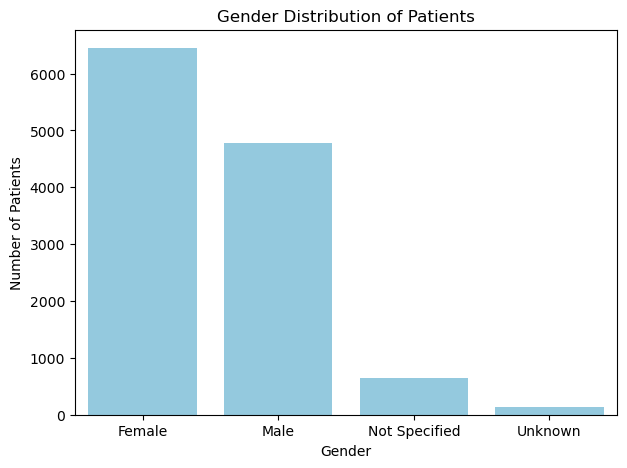

In [47]:

df_patient['gender'] = df_patient['patient.patientsex'].map({
    '1': 'Male',
    '2': 'Female',
    '0': 'Unknown'
})

df_patient['gender'] = df_patient['gender'].fillna('Not Specified')
gender_counts = df_patient['gender'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=gender_counts.index, y=gender_counts.values,color='skyblue')
plt.title('Gender Distribution of Patients')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.show()


In [43]:
df_drug = pd.json_normalize(
    data=records,
    record_path=["patient", "drug"],
    meta=["safetyreportid"],    
    record_prefix="drug.",
    meta_prefix="report.",
    sep="."
)

In [ ]:
print('##########################Check Homogeneity of drug columns #########################')

for column in df_drug.columns:
    non_null_series = df_drug[column].dropna()
    
    if non_null_series.empty:
        print(f"⚠️ Column: {column} has only null values — can't assess homogeneity.\n")
        continue
    
    types = non_null_series.map(type).value_counts()
    
    if len(types) > 1:
        print(f"❌ Column: {column} has mixed types:")
        print(types, "\n")
    else:
        print(f"✅ Column: {column} is homogeneous: {types.index[0].__name__}\n")


In [ ]:
print('#########################Missing Value percentage############################')
percent_missing = df_drug.isnull().sum() * 100 / len(df_drug)

missing_value_df = pd.DataFrame({
    'column_name': df_drug.columns,
    'percent_missing': percent_missing.values
})

# Sort by percentage
missing_value_df.sort_values('percent_missing', ascending=False, inplace=True)

# ✅ Print result
print(missing_value_df)

In [ ]:
print("\n#################### Constant Columns in df_drug ####################")

for col in df_drug.columns:
    most_common_value = df_drug[col].value_counts(dropna=False).iloc[0]
    frequency = df_drug[col].value_counts(dropna=False).iloc[0]
    ratio = frequency / len(df_drug)

    if ratio == 1.0:
        print(f"Column '{col}' is constant — value: {most_common_value} (100%)")

# Top 10 Most Common Drugs Given to Patients using the drug.medicinalproduct column!

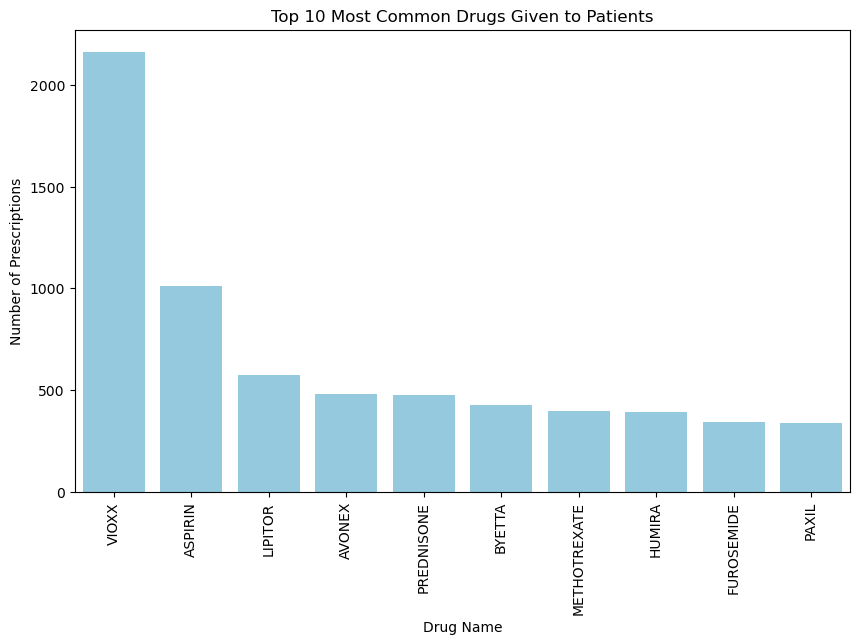

In [46]:
# Count the frequency of each drug name in 'drug.medicinalproduct'
top_drugs = df_drug['drug.medicinalproduct'].value_counts().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top_drugs.values, x=top_drugs.index,color='skyblue')
plt.xticks(rotation=90)
plt.title('Top 10 Most Common Drugs Given to Patients')
plt.ylabel('Number of Prescriptions')
plt.xlabel('Drug Name')
plt.show()


In [17]:

### ---------- STEP 2: Flatten patient.reaction ----------
df_reaction = pd.json_normalize(
    data=records,
    record_path=["patient", "reaction"],
    meta=["safetyreportid"],    
    record_prefix="reaction.",
    meta_prefix="report.",
    sep="."
)
print(df_reaction.head())


In [ ]:
print('##########################Check Homogeneity of reaction columns #########################')

for column in df_reaction.columns:
    non_null_series = df_reaction[column].dropna()
    
    if non_null_series.empty:
        print(f"⚠️ Column: {column} has only null values — can't assess homogeneity.\n")
        continue
    
    types = non_null_series.map(type).value_counts()
    
    if len(types) > 1:
        print(f"❌ Column: {column} has mixed types:")
        print(types, "\n")
    else:
        print(f"✅ Column: {column} is homogeneous: {types.index[0].__name__}\n")

In [ ]:
print('#########################Missing Value percentage############################')
percent_missing = df_reaction.isnull().sum() * 100 / len(df_reaction)

missing_value_df = pd.DataFrame({
    'column_name': df_reaction.columns,
    'percent_missing': percent_missing.values
})

# Sort by percentage
missing_value_df.sort_values('percent_missing', ascending=False, inplace=True)


# ✅ Print result
print(missing_value_df)

In [ ]:
print("\n#################### Constant Columns in df_reaction ####################")

for col in df_reaction.columns:
    most_common_value = df_reaction[col].value_counts(dropna=False).iloc[0]
    frequency = df_reaction[col].value_counts(dropna=False).iloc[0]
    ratio = frequency / len(df_reaction)

    if ratio == 1.0:
        print(f"Column '{col}' is constant — value: {most_common_value} (100%)")


![My Diagram](ER.png)